# 연령대별 보험 가입 패턴 분석

## 분석 질문
20~30대는 다른 연령대와 어떻게 다른 보험을 보유하고 있으며,
그 차이는 연령 자체에서 오는가?

## 데이터
AI Hub「금융상품·서비스 및 소비자 특성 데이터」Training 소비자 데이터

## 주의
특정 보험사(미래에셋생명) 계약 데이터로, 국내 보험시장 전체를 대표하지 않음

## 임포트와 경로

In [46]:
import zipfile, json, pathlib, re
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

root = pathlib.Path(r"D:\ai-campus-project\ABA_1st_proj_수정")
LBL = next(root.rglob("02.라벨링데이터"))
RAW = LBL.parent / "01.원천데이터"

print(RAW.exists(), LBL.exists())

True True


In [48]:
with zipfile.ZipFile(LBL / "TL_2.소비자.zip") as zf:
    with zf.open("소비자.csv") as f:
        con = pd.read_csv(f, encoding="utf-8")

print("전체:", con.shape)
con.head(10)

전체: (385019, 22)


,customer_id,customer_seq,customer_type,age,gender,region,income_bracket,occupation_group,risk_grade,credit_rating,marital_status,investment_propensity,cross_coverage,disease_history,product_name,product_amt,product_period,transaction_type,transaction_keyword,transaction_amt,transaction_start_year,transaction_last_year
0,70366f8a547028962bb5e476979d6f4fe9cc3bf14a2491...,1,보험,20대,남,경기도,3000만원미만,비경제활동인구,A,700점대,기혼,-,기타only,없음,연금저축 SAVE연금보험1104,400000,2044,정상,종속 특약,100000,2024,2025
1,eb20df62d84a34645098febb4a9124ccda73408ae2c084...,1,보험,20대,남,경기도,3000만원미만,비경제활동인구,A,300점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,1000000,2044,정상,종속 특약,100000,2024,2025
2,fac63ec523f4d21b1992d516f7d02be0db3d013456f0be...,1,보험,20대,남,경기도,3000만원미만,비경제활동인구,A,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,10000000,2045,정상,독립특약,100000,2025,2025
3,f2453b0ddb1be306c75c12505c4853d13c5d18e06d4c4e...,1,보험,20대,남,경기도,3000만원미만,사무종사자,A,900점대이상,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,36000000,2035,정상,종속 특약,100000,2024,2025
4,ff681c97a92bc1eda94031e8c4f5a37853a1f31f60ba0d...,1,보험,20대,남,경기도,5000만원미만,비경제활동인구,A,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,10000000,2044,정상,종속 특약,100000,2024,2025
5,1957702a103468972a05aefab1cf773331bfc6e94d1d8d...,1,보험,20대,남,경상도,3000만원미만,비경제활동인구,A,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,10000000,2034,정상,종속 특약,100000,2024,2025
6,9476918d8f6210798c0ec61b325e6944cd8a428a009fbe...,1,보험,20대,남,경상도,3000만원미만,서비스 종사자,B,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,3000000,2071,정상,종속 특약,100000,2024,2025
7,337e450f5bfc81d7f3e95a3dcf2afdfb91375d690c09dd...,1,보험,20대,남,인천,5000만원미만,서비스 종사자,B,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,200000,2045,정상,독립특약,100000,2025,2025
8,6321dd872b2decb3fa3e42875a6c3d6932379d05bb8258...,1,보험,20대,남,전라도,5000만원미만,판매종사자,B,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,200000,2044,정상,종속 특약,100000,2011,2025
9,8a71b29c831c17a92a7b39cf59440576f1eeb7defeaeda...,1,보험,20대,남,경기도,3000만원미만,전문가 및 관련 종사자,A,900점대이상,미혼,-,변액only,근골격계+척추계,미래에셋생명 변액연금보험 무배당 최저연금미보증형,12000000,9999,정상,주보험,100000,2024,2025


In [49]:
print("[결측률]")
print(con.isna().mean().round(4))

print("\n[고유값 수]")
print(con.nunique())

print("\n[customer_type]")
print(con["customer_type"].value_counts())

print("\n[age 원본]")
print(con["age"].value_counts())

[결측률]
customer_id               0.0
customer_seq              0.0
customer_type             0.0
age                       0.0
gender                    0.0
region                    0.0
income_bracket            0.0
occupation_group          0.0
risk_grade                0.0
credit_rating             0.0
marital_status            0.0
investment_propensity     0.0
cross_coverage            0.0
disease_history           0.0
product_name              0.0
product_amt               0.0
product_period            0.0
transaction_type          0.0
transaction_keyword       0.0
transaction_amt           0.0
transaction_start_year    0.0
transaction_last_year     0.0
dtype: float64

[고유값 수]
customer_id               335506
customer_seq                  34
customer_type                  2
age                            8
gender                         2
region                        11
income_bracket                 7
occupation_group              14
risk_grade                     6
credit_rating

In [50]:
print(ins["occupation_group"].value_counts())
print(pd.crosstab(ins["occupation_group"], ins["cat"], normalize="index").round(3) * 100)
print(pd.crosstab(ins["occupation_group"], ins["age"], normalize="index").round(3) * 100)

occupation_group
비경제활동인구             19866
사무종사자               14302
판매종사자                8804
전문가 및 관련 종사자         8758
기타                   7423
서비스 종사자              7298
관리자                  7160
장치·기계조작 및 조립 종사자     3694
Name: count, dtype: int64
cat               건강·질병   기타    암  연금·저축   정기   종신
occupation_group                                  
관리자                74.5  3.4  2.6   12.4  1.7  5.3
기타                 78.1  4.5  3.0    8.2  1.7  4.5
비경제활동인구            71.1  3.5  2.4   17.3  0.9  4.8
사무종사자              67.8  3.5  2.4   18.2  1.8  6.2
서비스 종사자            73.8  4.0  2.9   13.7  0.8  4.8
장치·기계조작 및 조립 종사자   80.1  2.8  2.5    8.2  1.6  4.9
전문가 및 관련 종사자       71.2  3.6  2.3   15.9  1.2  5.9
판매종사자              73.3  3.3  2.6   14.4  1.1  5.2
age                20대   30대   40대   50대   60대   70대
occupation_group                                    
관리자                3.9  14.2  22.4  34.2  23.3   1.9
기타                 2.5  11.0  15.0  29.1  32.1  10.3
비경제활동인구           13.9   7.

In [51]:
sub = ins[ins["age"].isin(["30대","40대"])]
print(pd.crosstab([sub["age"], sub["occupation_group"]], sub["cat"],
                  normalize="index").round(3) * 100)

cat                   건강·질병   기타    암  연금·저축   정기   종신
age occupation_group                                  
30대 관리자                71.8  2.6  1.7   17.0  1.8  5.2
    기타                 82.6  3.2  1.1    6.8  2.3  4.1
    비경제활동인구            68.5  2.2  1.6   22.7  1.0  4.0
    사무종사자              67.9  3.0  1.7   19.7  2.0  5.7
    서비스 종사자            77.2  1.4  1.3   15.3  1.1  3.8
    장치·기계조작 및 조립 종사자   80.4  1.9  2.8    8.2  1.9  4.9
    전문가 및 관련 종사자       73.1  2.2  2.2   16.8  1.5  4.2
    판매종사자              76.0  2.4  1.9   14.9  0.9  3.9
40대 관리자                75.5  3.0  1.7   11.0  2.4  6.3
    기타                 77.0  4.9  2.3    7.9  2.2  5.7
    비경제활동인구            71.2  3.0  2.3   17.7  0.9  4.9
    사무종사자              70.8  3.5  2.9   14.9  1.6  6.4
    서비스 종사자            77.1  3.4  3.2   10.1  1.0  5.1
    장치·기계조작 및 조립 종사자   79.6  2.6  1.6    8.2  2.0  6.0
    전문가 및 관련 종사자       73.2  3.6  2.1   13.2  1.2  6.7
    판매종사자              70.1  2.9  3.0   15.7  1.8  6.5


In [52]:
sub = ins[ins["occupation_group"]=="비경제활동인구"]
print(pd.crosstab(sub["age"], sub["cat"], normalize="index").round(3) * 100)

cat  건강·질병   기타    암  연금·저축   정기   종신
age                                  
20대   71.9  2.2  1.3   20.4  0.6  3.7
30대   68.5  2.2  1.6   22.7  1.0  4.0
40대   71.2  3.0  2.3   17.7  0.9  4.9
50대   70.5  3.4  3.2   15.9  1.5  5.4
60대   72.5  4.0  2.8   15.0  0.8  4.8
70대   70.3  4.7  2.2   17.4  0.5  4.9


In [53]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rc("font", family="Malgun Gothic")
mpl.rc("axes", unicode_minus=False)
sns.set_theme(style="whitegrid", font="Malgun Gothic")

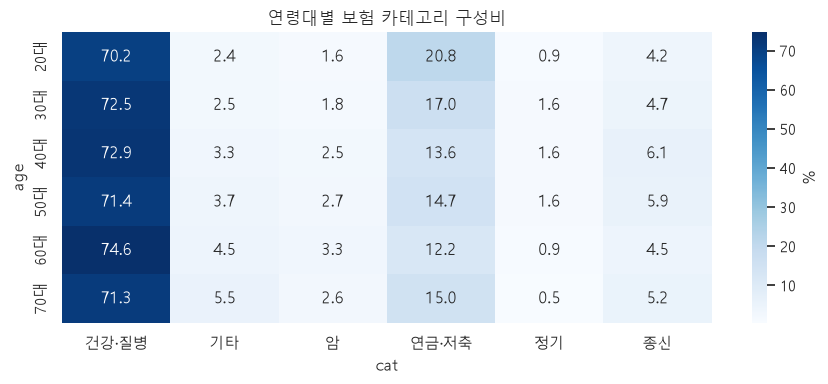

In [54]:
mix = (pd.crosstab(ins["age"], ins["cat"], normalize="index") * 100)
mix = mix.reindex(["20대","30대","40대","50대","60대","70대"])

plt.figure(figsize=(9, 4))
sns.heatmap(mix, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "%"})
plt.title("연령대별 보험 카테고리 구성비")
plt.tight_layout()

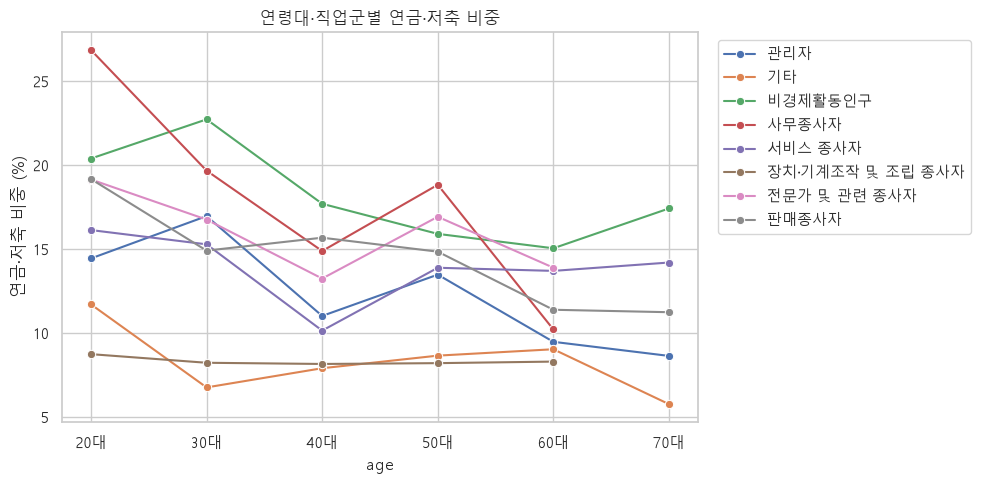

In [55]:
g = (ins.assign(sav=(ins["cat"]=="연금·저축").astype(int))
        .groupby(["occupation_group","age"])["sav"].agg(["mean","count"]))
g = g[g["count"] >= 100].reset_index()
g["mean"] *= 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=g, x="age", y="mean", hue="occupation_group", marker="o")
plt.title("연령대·직업군별 연금·저축 비중")
plt.ylabel("연금·저축 비중 (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

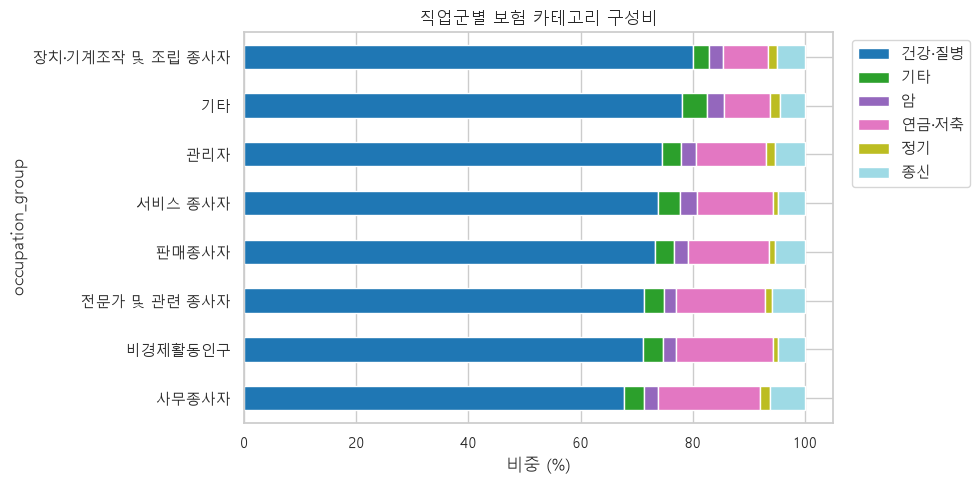

In [56]:
occ = (pd.crosstab(ins["occupation_group"], ins["cat"], normalize="index") * 100)
occ = occ.sort_values("연금·저축", ascending=False)

occ.plot(kind="barh", stacked=True, figsize=(10, 5), colormap="tab20")
plt.title("직업군별 보험 카테고리 구성비")
plt.xlabel("비중 (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

In [59]:
plt.savefig("reports/fig_pension_by_age_occ.png", dpi=150, bbox_inches="tight")

FileNotFoundError: [Errno 2] No such file or directory: 'reports/fig_pension_by_age_occ.png'

<Figure size 640x480 with 0 Axes>

In [58]:
[f.name for f in mpl.font_manager.fontManager.ttflist if "Gothic" in f.name]

['Franklin Gothic Medium Cond',
 'Malgun Gothic',
 'Franklin Gothic Medium',
 'Malgun Gothic',
 'Century Gothic',
 'Franklin Gothic Heavy',
 'Malgun Gothic',
 'Malgun Gothic Semilight',
 'Franklin Gothic Medium',
 'Franklin Gothic Book',
 'Franklin Gothic Heavy',
 'Copperplate Gothic Bold',
 'Franklin Gothic Book',
 'Century Gothic',
 'Yu Gothic',
 'Yu Gothic UI',
 'Yu Gothic UI Semilight',
 'MS Gothic',
 'MS UI Gothic',
 'MS PGothic',
 'Century Gothic',
 'Century Gothic',
 'Yu Gothic',
 'Yu Gothic UI',
 'Yu Gothic UI',
 'Yu Gothic UI Semibold',
 'Yu Gothic',
 'Yu Gothic Medium',
 'Yu Gothic UI',
 'Copperplate Gothic Light',
 'Showcard Gothic',
 'Franklin Gothic Demi',
 'Yu Gothic',
 'Yu Gothic Light',
 'Yu Gothic UI',
 'Yu Gothic UI Light',
 'Franklin Gothic Demi',
 'Franklin Gothic Demi Cond']

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

ins["is_savings"] = (ins["cat"] == "연금·저축").astype(int)
feat = ["age","gender","region","income_bracket","occupation_group",
        "credit_rating","marital_status","disease_history"]

X, y = ins[feat], ins["is_savings"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

enc = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), feat)])

models = {
    "기준선": DummyClassifier(strategy="stratified", random_state=42),
    "로지스틱": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "랜덤포레스트": RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                    class_weight="balanced", random_state=42, n_jobs=-1),
}

rows = []
fitted = {}
for name, m in models.items():
    pipe = Pipeline([("enc", enc), ("clf", m)]).fit(Xtr, ytr)
    p = pipe.predict_proba(Xte)[:, 1]
    rows.append({"모델": name,
                 "ROC-AUC": roc_auc_score(yte, p),
                 "PR-AUC": average_precision_score(yte, p)})
    fitted[name] = pipe

print(f"양성 비율: {y.mean():.3f}")
print(pd.DataFrame(rows).round(3))

양성 비율: 0.149
       모델  ROC-AUC  PR-AUC
0     기준선    0.502   0.149
1    로지스틱    0.709   0.288
2  랜덤포레스트    0.740   0.355


In [61]:
pipe = fitted["로지스틱"]
names = pipe.named_steps["enc"].get_feature_names_out()
coef = pipe.named_steps["clf"].coef_[0]
res = pd.DataFrame({"변수": names, "계수": coef, "오즈비": np.exp(coef)})

print(res[res["변수"].str.contains("age")].sort_values("오즈비", ascending=False))
print(res[res["변수"].str.contains("occupation")].sort_values("오즈비", ascending=False))

            변수        계수       오즈비
0  oh__age_20대  0.142654  1.153331
3  oh__age_50대  0.072179  1.074848
1  oh__age_30대 -0.006298  0.993722
2  oh__age_40대 -0.088577  0.915233
5  oh__age_70대 -0.180989  0.834444
4  oh__age_60대 -0.196196  0.821851
                                       변수        계수       오즈비
25             oh__occupation_group_사무종사자  0.320945  1.378429
24           oh__occupation_group_비경제활동인구  0.149456  1.161202
22               oh__occupation_group_관리자  0.057612  1.059304
29             oh__occupation_group_판매종사자  0.054940  1.056478
26           oh__occupation_group_서비스 종사자 -0.033916  0.966652
28      oh__occupation_group_전문가 및 관련 종사자 -0.053590  0.947820
27  oh__occupation_group_장치·기계조작 및 조립 종사자 -0.323978  0.723266
23                oh__occupation_group_기타 -0.428695  0.651359


In [63]:
# 6개 카테고리 다중분류 — "이 고객에게 뭘 제안할까"
y_multi = ins["cat"]

In [64]:
print("교차항 포함:",
      round(roc_auc_score(yte, p), 3),
      round(average_precision_score(yte, p), 3))

교차항 포함: 0.727 0.333


In [65]:
print(f"교차항 포함: ROC-AUC {roc_auc_score(yte, p):.3f}, PR-AUC {average_precision_score(yte, p):.3f}")

교차항 포함: ROC-AUC 0.727, PR-AUC 0.333


In [66]:
VAL = next(root.rglob("Validation"))
val_zip = next(VAL.rglob("TL_2.소비자.zip"))

with zipfile.ZipFile(val_zip) as zf:
    with zf.open("소비자.csv") as f:
        con_val = pd.read_csv(f, encoding="utf-8")

print("Training:", con.shape, " Validation:", con_val.shape)
print("완전 동일:", con.equals(con_val))

StopIteration: 

In [67]:
VAL = next(root.rglob("Validation"))
for p in sorted(VAL.rglob("*.zip")):
    print(p.relative_to(VAL))

01.원천데이터\VS_1.상품_1.증권_01.주식형.zip
01.원천데이터\VS_1.상품_1.증권_02.채권형.zip
01.원천데이터\VS_1.상품_1.증권_03.재간접.zip
01.원천데이터\VS_1.상품_1.증권_04.단기금융.zip
01.원천데이터\VS_1.상품_1.증권_05.파생형.zip
01.원천데이터\VS_1.상품_1.증권_06.퇴직연금.zip
01.원천데이터\VS_1.상품_2.보험_01.연금.zip
01.원천데이터\VS_1.상품_2.보험_02.종신.zip
01.원천데이터\VS_1.상품_2.보험_03.정기.zip
01.원천데이터\VS_1.상품_2.보험_04.질병.zip
01.원천데이터\VS_1.상품_2.보험_05.건강.zip
01.원천데이터\VS_1.상품_2.보험_06.암.zip
01.원천데이터\VS_1.상품_2.보험_07.변액.zip
02.라벨링데이터\VL_1.CoT_1.증권_01.고객특성 강조형.zip
02.라벨링데이터\VL_1.CoT_1.증권_02.투자성향 및 조건기반형.zip
02.라벨링데이터\VL_1.CoT_1.증권_03.상품 비교 추천형.zip
02.라벨링데이터\VL_1.CoT_2.보험_01.연령별 및 생애주기 저축성 상품 추천형.zip
02.라벨링데이터\VL_1.CoT_2.보험_02.투자성 상품 추천형.zip
02.라벨링데이터\VL_1.CoT_2.보험_03.건강 및 질병보장 대비형.zip
02.라벨링데이터\VL_2.소비자.zip


In [68]:
sav = ins.assign(s=(ins["cat"]=="연금·저축").astype(int))

# ① 같은 나이 안에서 직업별 편차
byage = (sav.groupby(["age","occupation_group"])["s"]
           .agg(["mean","count"]).query("count >= 100"))
spread_age = (byage.groupby("age")["mean"]
                .agg(["max","min"]).assign(격차=lambda d: (d["max"]-d["min"])*100))
print(spread_age.round(3))

# ② 같은 직업 안에서 나이별 편차
byocc = (sav.groupby(["occupation_group","age"])["s"]
           .agg(["mean","count"]).query("count >= 100"))
spread_occ = (byocc.groupby("occupation_group")["mean"]
                .agg(["max","min"]).assign(격차=lambda d: (d["max"]-d["min"])*100))
print(spread_occ.round(3))

       max    min      격차
age                      
20대  0.269  0.087  18.116
30대  0.227  0.068  15.967
40대  0.177  0.079   9.796
50대  0.188  0.082  10.625
60대  0.150  0.083   6.750
70대  0.174  0.058  11.658
                    max    min      격차
occupation_group                      
관리자               0.170  0.086   8.328
기타                0.117  0.058   5.943
비경제활동인구           0.227  0.150   7.680
사무종사자             0.269  0.102  16.644
서비스 종사자           0.161  0.101   5.988
장치·기계조작 및 조립 종사자  0.087  0.082   0.584
전문가 및 관련 종사자      0.191  0.132   5.900
판매종사자             0.192  0.112   7.932


In [69]:
occ_age = pd.crosstab(ins["occupation_group"], ins["age"])
print(occ_age)

sub = ins[ins["occupation_group"]=="사무종사자"]
print(pd.crosstab(sub["age"], sub["income_bracket"], normalize="index").round(3)*100)

age                20대   30대   40대   50대   60대   70대
occupation_group                                    
관리자                277  1020  1607  2449  1668   139
기타                 188   814  1114  2162  2381   764
비경제활동인구           2761  1439  2300  4188  5291  3887
사무종사자             1780  3574  4173  3580  1097    98
서비스 종사자            620   877   996  2276  2212   317
장치·기계조작 및 조립 종사자   103   535   834  1268   856    98
전문가 및 관련 종사자       862  2071  2462  2807   540    16
판매종사자              553  1429  2067  2486  2091   178
income_bracket  10000만원이상  3000만원미만  5000만원미만  8000만원미만
age                                                    
20대                   0.7      59.4      33.2       6.7
30대                   2.4      36.7      32.4      28.5
40대                   9.9      10.3      48.3      31.5
50대                  11.3       5.3      51.1      32.2
60대                   7.7      26.6      40.4      25.3
70대                   3.1      28.6      29.6      38.8


In [70]:
recent = ins[ins["start"] >= 2023]
r = recent.assign(s=(recent["cat"]=="연금·저축").astype(int))
print(r.groupby(["occupation_group","age"])["s"].agg(["mean","count"]).query("count>=50").round(3))

                       mean  count
occupation_group age              
관리자              20대  0.141    262
                 30대  0.174    962
                 40대  0.104   1470
                 50대  0.123   2184
                 60대  0.092   1489
                 70대  0.096    125
기타               20대  0.112    170
                 30대  0.061    770
                 40대  0.068    990
                 50대  0.076   1977
                 60대  0.080   2073
                 70대  0.051    668
비경제활동인구          20대  0.199   2623
                 30대  0.227   1366
                 40대  0.170   2088
                 50대  0.143   3783
                 60대  0.141   4742
                 70대  0.163   3503
사무종사자            20대  0.276   1666
                 30대  0.198   3354
                 40대  0.149   3770
                 50대  0.182   3157
                 60대  0.098    983
                 70대  0.182     88
서비스 종사자          20대  0.147    571
                 30대  0.150    834
                 40대